### Lab task 2: AR-model estimation

Fitting parametric models to data is a powerful way of extracting information from noisy measurements. In particular, using a model can often be more efficient in data usage as compared to non-parametric methods in the sense that considerably fewer measurements are needed to achieve the same quality of the information retrieved.

However, a model is only useful if it provides a reasonably accurate description of the data – using the ”wrong” model may actually hurt you. An overly simplistic model may fail to capture important data characteristics. On the other hand, a more complicated model that fits the data well may have too many parameters to be accurately estimated from a finite number of measurements.

This task is concerned with estimating the parameters of autoregressive (AR) models from noisy data.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import io
import pandas as pd

In [ ]:
# Load data
data = io.loadmat('../data/ar_data.mat')
print(data.keys())

y = data['y']
df = pd.DataFrame(y, columns=['y'])

dict_keys(['__header__', '__version__', '__globals__', 'y'])


In [ ]:
# First rows
print(df.head())

          y
0 -4.468043
1 -4.528863
2 -2.802937
3 -0.131094
4  0.442659


In [31]:
# Data info
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       500 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB
None


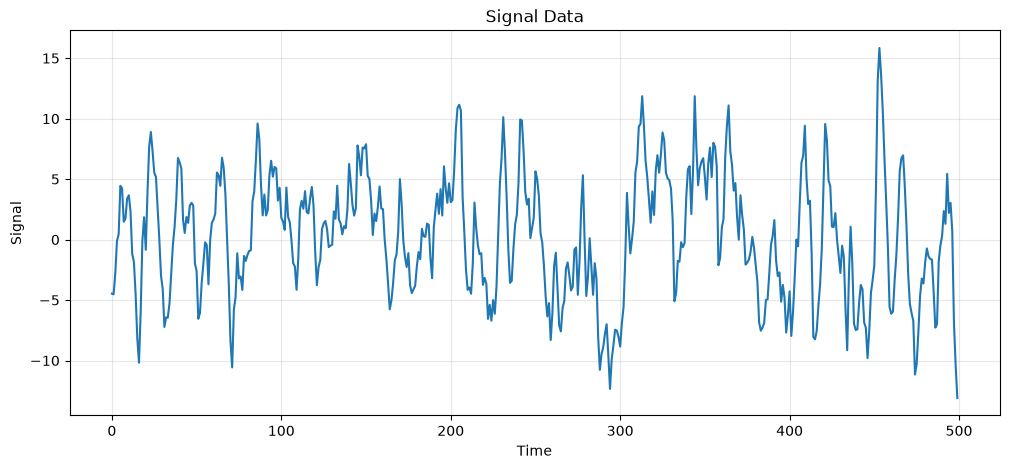

In [32]:
# Plot
plt.figure(figsize=(12, 5))
plt.plot(y)
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Signal Data')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# Calculate covariance with pandas
covariance = df.cov()
print("Covariance Matrix:")
print(covariance)

# Calculate autocorrelation with pandas
autocorr = df.autocorr()
print("\nAutocorrelation (lag 1):")
print(autocorr)

Covariance Matrix:
           y
y  25.240654


AttributeError: 'DataFrame' object has no attribute 'autocorr'

In [ ]:
# Plot 50 first lags
plt.figure(figsize=(12, 5))
plt.stem(lags, acf[:50])
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function - First 50 Lags')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cargar el archivo .mat
data = loadmat("ar_data.mat")
y = data["y"].flatten()   # Convertir a vector 1D

# Número máximo de lags
max_lag = 50

# Centrar la señal
y_centered = y - np.mean(y)

# Calcular la autocovarianza (estimador sesgado)
cov = np.correlate(y_centered, y_centered, mode="full")
cov = cov[len(y)-1 : len(y)+max_lag] / len(y)

# Vector de lags
lags = np.arange(len(cov))

# Graficar
plt.figure(figsize=(8, 4))
plt.stem(lags, cov)
plt.xlabel("Lag")
plt.ylabel("Covarianza")
plt.title("Función de covarianza de y (primeros 50 lags)")
plt.grid(True)
plt.show()
Interpretación (para responder la pregunta)

Ruido blanco: la covarianza es grande solo en el lag 0 y los demás valores están cerca de 0 sin un patrón claro.

Con estructura: varios lags tienen covarianzas apreciables (positivas o negativas), mostrando un decaimiento u oscilación, lo que indica dependencia temporal y sugiere un proceso autorregresivo (AR).